# Phase 1 — Exploration des données

**Objectif du notebook :**
Charger, nettoyer et explorer les données BTC/ETH.
À la fin, on doit pouvoir répondre à :
1. Les données sont-elles propres et bien alignées ?
2. Quelle est la distribution des log-returns ?
3. La corrélation BTC/ETH est-elle stable dans le temps ?

---

In [11]:
import sys
sys.path.append('..')  # Pour importer depuis src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.processing.cleaning import load_ohlcv, align_pairs, detect_gaps
from src.features.features import log_returns, rolling_zscore, rolling_correlation
from src.utils.plotting import plot_prices, plot_log_returns, plot_rolling_correlation

plt.style.use('seaborn-v0_8-whitegrid')

# chaque modification dans src/ est automatiquement rechargée sans avoir à faire importlib.reload à la main.
%load_ext autoreload
%autoreload 2

from pathlib import Path # pour gérer les chemins de fichiers de manière plus robuste

print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


## 1. Chargement et vérification des données

In [12]:
df_btc = load_ohlcv('BTCUSDT', '15m')
df_eth = load_ohlcv('ETHUSDT', '15m')

print('\nBTC — premières lignes :')
df_btc.head(3)

Chargé : BTCUSDT_15m — 293,600 bougies (2018-01-01 → 2026-05-22)
Chargé : ETHUSDT_15m — 293,600 bougies (2018-01-01 → 2026-05-22)

BTC — premières lignes :


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,857610.826999,0
2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,642281.172303,0
2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,590034.713160,0


In [13]:
# Vérification des gaps
print('=== Gaps BTC ===')
gaps_btc = detect_gaps(df_btc, timeframe_minutes=15)

print('\n=== Gaps ETH ===')
gaps_eth = detect_gaps(df_eth, timeframe_minutes=15)

=== Gaps BTC ===
30 gap(s) détecté(s) :
  2018-01-04  →  durée : 0 days 02:00:00
  2018-02-09  →  durée : 1 days 09:45:00
  2018-02-10  →  durée : 0 days 00:30:00
  2018-02-11  →  durée : 0 days 00:30:00
  2018-06-26  →  durée : 0 days 10:15:00
  2018-06-27  →  durée : 0 days 02:00:00
  2018-07-04  →  durée : 0 days 07:45:00
  2018-10-19  →  durée : 0 days 03:45:00
  2018-11-14  →  durée : 0 days 07:15:00
  2019-03-12  →  durée : 0 days 06:15:00
  2019-05-15  →  durée : 0 days 10:15:00
  2019-06-07  →  durée : 0 days 01:15:00
  2019-08-15  →  durée : 0 days 08:15:00
  2019-11-13  →  durée : 0 days 02:30:00
  2019-11-25  →  durée : 0 days 02:15:00
  2020-02-09  →  durée : 0 days 01:15:00
  2020-02-19  →  durée : 0 days 06:00:00
  2020-03-04  →  durée : 0 days 02:15:00
  2020-04-25  →  durée : 0 days 02:45:00
  2020-06-28  →  durée : 0 days 03:45:00
  2020-11-30  →  durée : 0 days 01:15:00
  2020-12-21  →  durée : 0 days 04:15:00
  2020-12-25  →  durée : 0 days 01:15:00
  2021-02-11  →  

In [14]:
# Alignement
df_btc, df_eth = align_pairs(df_btc, df_eth, name_a='BTC', name_b='ETH')
print(f'\nDataset final : {len(df_btc):,} bougies alignées')

Alignement BTC / ETH
  BTC : 293,600 bougies  →  perdues : 0
  ETH : 293,600 bougies  →  perdues : 0
  Timestamps communs : 293,600

Dataset final : 293,600 bougies alignées


## 2. Visualisation des prix bruts

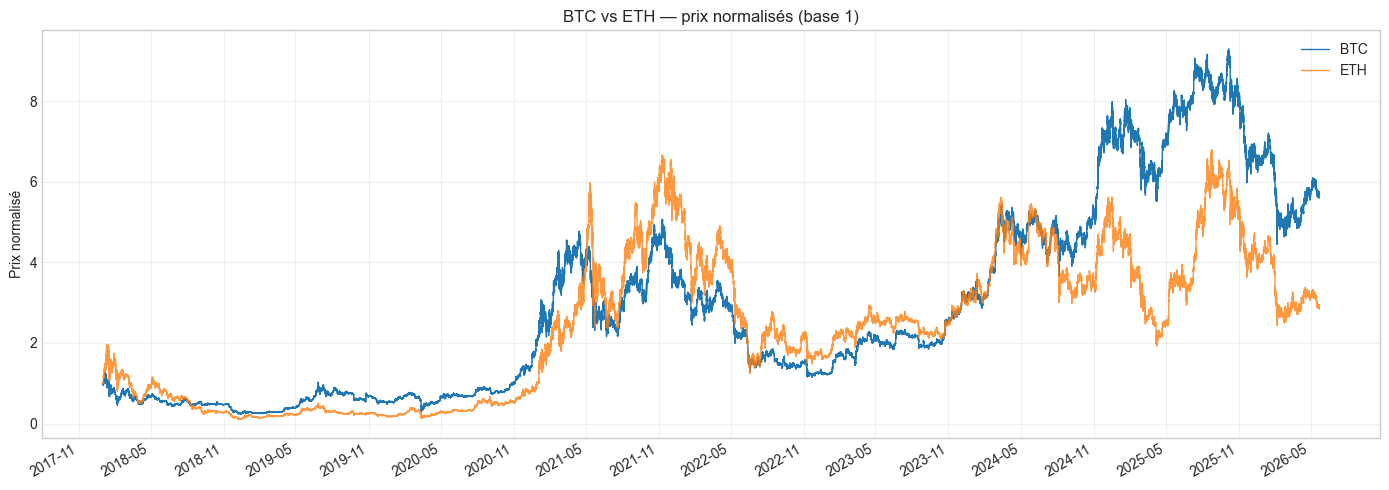

In [15]:
plot_prices(df_btc, df_eth, name_a='BTC', name_b='ETH')

## 3. Log-returns

$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$

On attend des log-returns :
- Centrés autour de 0 (preuve de stationnarité)
- Distribution proche d'une gaussienne (avec des queues épaisses en finance, car es événements extrêmes sont plus fréquents)
- Stationnarité visuelle (pas de tendance)

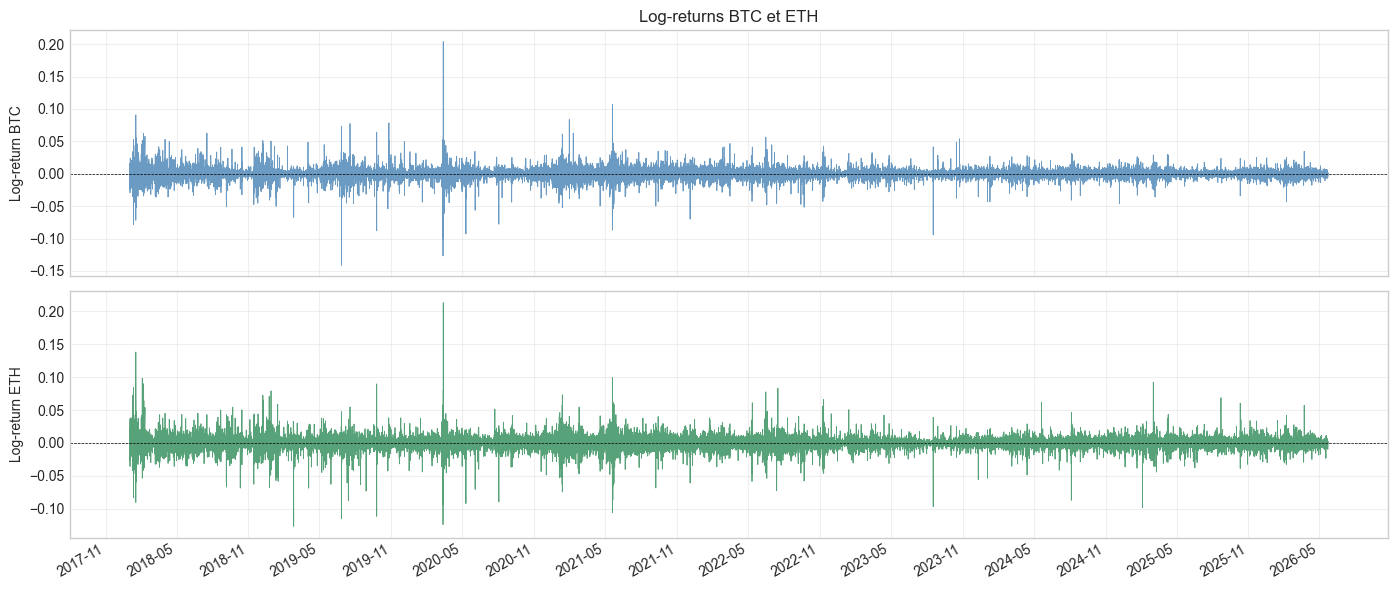

In [16]:
df_btc['log_return'] = log_returns(df_btc['Close'])
df_eth['log_return'] = log_returns(df_eth['Close'])

# On drop le premier NaN
ret_btc = df_btc['log_return'].dropna()
ret_eth = df_eth['log_return'].dropna()

plot_log_returns(ret_btc, ret_eth)

In [17]:
# Statistiques descriptives
stats = pd.DataFrame({
    'BTC': ret_btc.describe(),
    'ETH': ret_eth.describe()
})

# Ajouter skewness et kurtosis
stats.loc['skewness'] = [ret_btc.skew(), ret_eth.skew()]
stats.loc['kurtosis'] = [ret_btc.kurtosis(), ret_eth.kurtosis()]

print('Statistiques des log-returns :')
print(stats.round(6))
print('\nNote : kurtosis > 0 = queues plus épaisses qu\'une gaussienne (leptokurtique)')
print('C\'est normal et attendu')

Statistiques des log-returns :
                    BTC            ETH
count     293599.000000  293599.000000
mean           0.000006       0.000004
std            0.003709       0.004686
min           -0.141241      -0.126609
25%           -0.001277      -0.001713
50%            0.000013       0.000017
75%            0.001321       0.001766
max            0.203992       0.213237
skewness       0.075709      -0.037843
kurtosis      87.207384      57.518141

Note : kurtosis > 0 = queues plus épaisses qu'une gaussienne (leptokurtique)
C'est normal et attendu


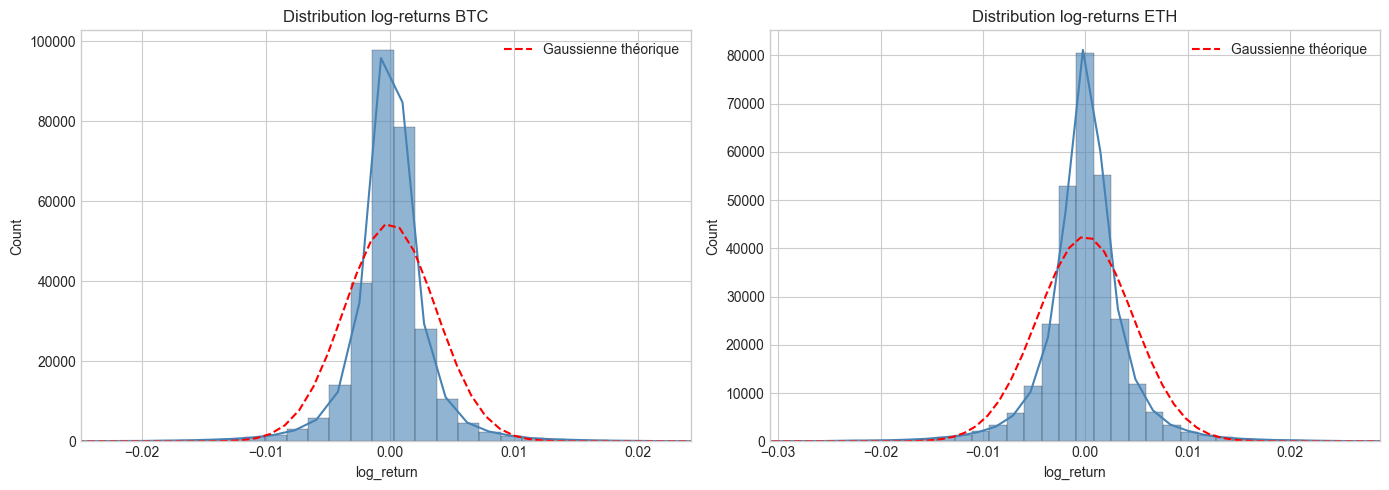

Les queues sont plus épaisses que la gaussienne : les crashes/rallyes sont plus fréquents que prévu


In [18]:
# Distribution des log-returns vs gaussienne
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ret, name in zip(axes, [ret_btc, ret_eth], ['BTC', 'ETH']):
    sns.histplot(ret, bins=200, kde=True, ax=ax, color='steelblue', alpha=0.6)
    
    # Gaussienne théorique
    x = np.linspace(ret.min(), ret.max(), 300)
    from scipy import stats as scipy_stats
    gauss = scipy_stats.norm.pdf(x, ret.mean(), ret.std())
    ax.plot(x, gauss * len(ret) * (ret.max() - ret.min()) / 200,
            color='red', linewidth=1.5, linestyle='--', label='Gaussienne théorique')
    
    ax.set_xlim(ret.quantile(0.001), ret.quantile(0.999))
    ax.set_title(f'Distribution log-returns {name}')
    ax.legend()

plt.tight_layout()
plt.show()
print('Les queues sont plus épaisses que la gaussienne : les crashes/rallyes sont plus fréquents que prévu')

## 4. Corrélation mobile BTC/ETH

Si la corrélation est haute et stable → bonne candidate pour le pair trading.
Si elle s'effondre régulièrement → la paire est moins fiable.

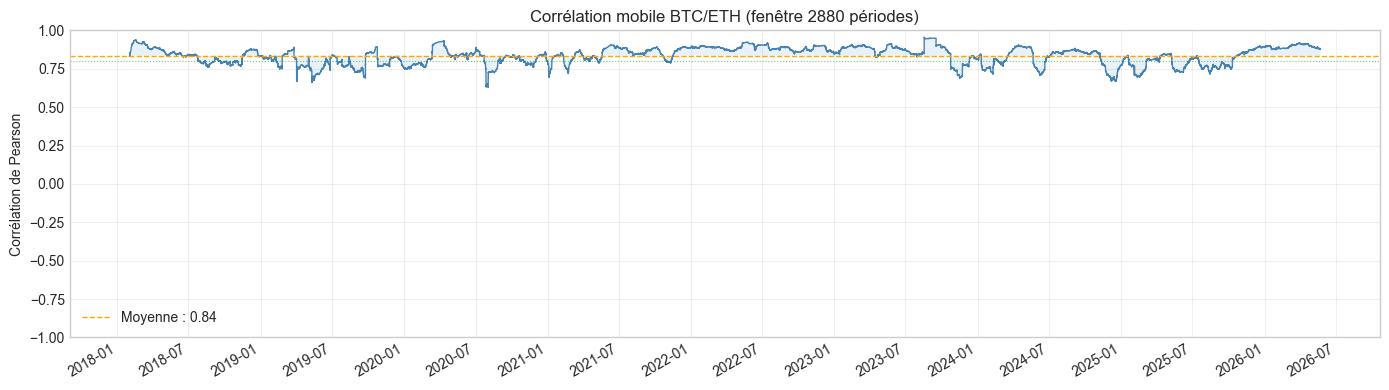

Corrélation moyenne sur 30 jours : 0.835
Corrélation min : 0.630
Corrélation max : 0.956


In [19]:
# Fenêtre de 30 jours = 30 * 24 * 4 = 2880 bougies de 15m
window_30d = 30 * 24 * 4

corr_30d = rolling_correlation(ret_btc, ret_eth, window=window_30d)
plot_rolling_correlation(corr_30d, window=window_30d)

print(f'Corrélation moyenne sur 30 jours : {corr_30d.mean():.3f}')
print(f'Corrélation min : {corr_30d.min():.3f}')
print(f'Corrélation max : {corr_30d.max():.3f}')

## 5. Exports finaux (parquet)

In [20]:
PROCESSED_DIR = Path('..') / 'data' / 'processed'

df_btc.to_parquet(PROCESSED_DIR / 'BTCUSDT_15m_clean.parquet')
df_eth.to_parquet(PROCESSED_DIR / 'ETHUSDT_15m_clean.parquet')

## Conclusion Phase 1

**Ce qu'on a établi :**
- [ ] Les données BTC/ETH sont chargées, nettoyées et alignées
- [ ] Nombre de gaps identifiés et compris
- [ ] Les log-returns sont calculés et leur distribution analysée
- [ ] La corrélation mobile BTC/ETH est visualisée

**Ce qu'on verra en Phase 2 :**
Vérifier formellement si BTC et ETH sont **cointégrés** — c'est-à-dire si le spread
$S_t = \text{BTC}_t - \beta \cdot \text{ETH}_t$ est stationnaire.
Une forte corrélation n'implique pas la cointégration, et c'est la cointégration
qui justifie mathématiquement la stratégie mean-reversion.